# To-bee - Acoustic input-gate & Queenless detection

**Dataset:** *To bee or not to bee* (NU-Hive + OSBH): 56 recordings with `.lab` files marking each interval **bee** vs **noBee**; filenames encode **queen state** (QueenBee/Active = queenright; NO_QueenBee/Missing Queen = queenless). Features: 13 MFCC + 9 spectral-shape descriptors; model: RandomForest.

**Two jobs, different in kind:**
1. **The gate** - is the mic actually hearing bees? An input-validity guard for every downstream model.
2. **Queenless** - given valid bee sound, has the colony lost its queen?

**The thesis of this notebook:** *how* you validate decides whether a result is real. We report every score both **within-hive** (random split) and **hive-held-out** (unseen colonies). The gap between them is the story. Format: *Question -> Plot -> Reasoning*.

## 0. Setup - load cached features
Feature extraction is done once by `src/tobee_loader.py` and cached to CSV, so this notebook is fast.

In [1]:
import os, sys, warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.join('..','src')); sys.path.insert(0, 'src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import tobee_loader as T
plt.rcParams.update({'figure.figsize':(11,4.5),'axes.grid':True,'grid.alpha':.25})
gate = pd.read_csv(os.path.join(T.CACHE_DIR,'gate_features.csv'))
queen = pd.read_csv(os.path.join(T.CACHE_DIR,'queen_features.csv'))
feats = T.feature_columns(gate)
print('gate  :', gate.shape, '| hives', gate.hive_id.nunique(), '| balance', gate.label.value_counts().to_dict())
print('queen :', queen.shape, '| hives', queen.hive_id.nunique(), '| balance', queen.label.value_counts().to_dict())
print('features:', len(feats), '| NOTE: only', gate.hive_id.nunique(), 'distinct colonies - small for cross-hive tests')

gate  : (1386, 25) | hives 6 | balance {1: 753, 0: 633}
queen : (56, 26) | hives 6 | balance {1: 29, 0: 27}
features: 22 | NOTE: only 6 distinct colonies - small for cross-hive tests


## 0.1 A reusable, leakage-aware evaluator

One helper, two protocols. **Within-hive** = StratifiedKFold (a colony can appear in train *and* test). **Hive-held-out** = GroupShuffleSplit on `hive_id` (a colony is in exactly one side). The first measures memorisation; the second measures generalisation to **new** colonies - the only thing a deployed fleet faces.

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GroupShuffleSplit
from sklearn.metrics import balanced_accuracy_score
def _rf(): return RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=0, n_jobs=-1)
def within_hive(X, y, k=5):
    s=[]
    for tr,te in StratifiedKFold(k, shuffle=True, random_state=0).split(X, y):
        s.append(balanced_accuracy_score(y[te], _rf().fit(X[tr],y[tr]).predict(X[te])))
    return np.mean(s), np.std(s)
def hive_held_out(X, y, g, n=8):
    s=[]
    for tr,te in GroupShuffleSplit(n, test_size=.3, random_state=0).split(X, y, g):
        if len(np.unique(y[tr]))<2 or len(np.unique(y[te]))<2: continue
        s.append(balanced_accuracy_score(y[te], _rf().fit(X[tr],y[tr]).predict(X[te])))
    return (np.mean(s), np.std(s), len(s))

# Task 1 - The gate (bee vs noBee)

## 1.1 Why a gate at all?
Field mics capture wind, traffic, rain and dead air. If a health model scores that, it emits confident nonsense. The gate is the system saying **"I can't trust my input right now"** - it runs first and cheaply.

## 1.2 What does bee vs noBee look like?
**Q:** Is there a visible spectral difference between a bee interval and a noise interval?

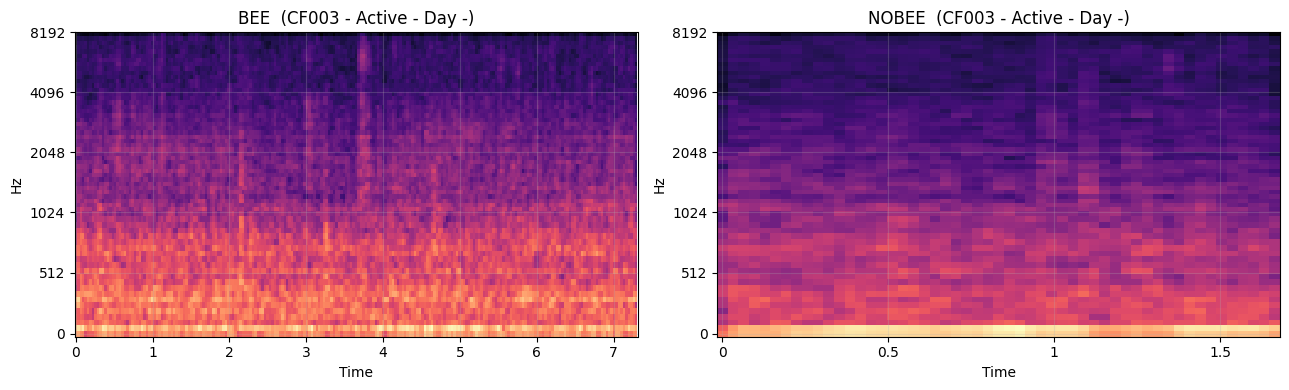

In [3]:
import librosa, librosa.display, glob
ex = sorted(glob.glob(os.path.join(T.TOBEE_DIR,'*.wav')))[0]
base = os.path.splitext(os.path.basename(ex))[0]
iv = T.parse_lab(os.path.join(T.TOBEE_DIR, base+'.lab'))
y, sr = librosa.load(ex, sr=T.SR)
def seg(label):
    for s,e,l in iv:
        if l==label and e-s>=1.5: return y[int(s*sr):int(e*sr)]
    return None
fig, ax = plt.subplots(1,2,figsize=(13,4))
for a,lab in zip(ax,['bee','nobee']):
    sg=seg(lab)
    if sg is None: a.set_title(f'no {lab} interval'); continue
    Sdb=librosa.power_to_db(librosa.feature.melspectrogram(y=sg,sr=sr,n_mels=64),ref=np.max)
    librosa.display.specshow(Sdb,sr=sr,x_axis='time',y_axis='mel',ax=a)
    a.set_title(f'{lab.upper()}  ({base[:22]})')
plt.tight_layout(); plt.show()

**Reasoning:** the bee interval shows a denser low-frequency hum; the noBee interval is flatter/sparser. But note both are recorded *at the hive*, so 'noBee' still leaks faint colony sound - we should expect the gate to be learnable but **not** trivially perfect.

## 1.3 Balance & feature separation
**Q:** Is the gate balanced, and do features separate the classes?

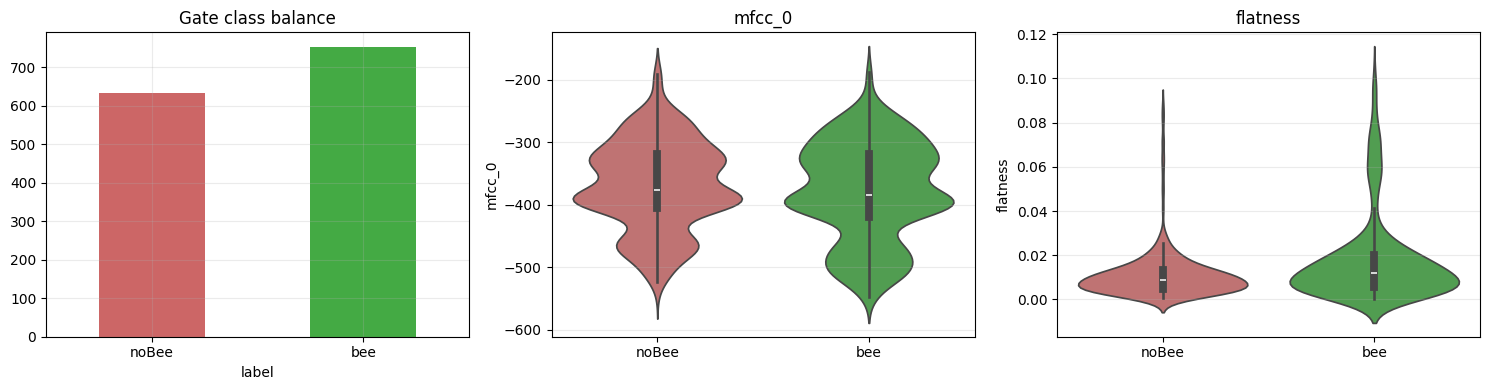

In [4]:
fig, ax = plt.subplots(1,3,figsize=(15,4))
gate.label.value_counts().sort_index().plot.bar(ax=ax[0], color=['#c66','#4a4'])
ax[0].set_xticklabels(['noBee','bee'], rotation=0); ax[0].set_title('Gate class balance')
for a,c in zip(ax[1:], ['mfcc_0','flatness']):
    sns.violinplot(data=gate, x='label', y=c, ax=a, palette=['#c66','#4a4'])
    a.set_xticklabels(['noBee','bee']); a.set_xlabel(''); a.set_title(c)
plt.tight_layout(); plt.show()

**Reasoning:** classes are roughly balanced and `mfcc_0` (energy) / `flatness` (noise-likeness) shift in the expected directions, so there is real, interpretable signal - the open question is whether it *transfers* across colonies.

## 1.4 Within-hive vs hive-held-out
**Q:** How much of the gate's apparent skill survives when the test colony was never seen in training?

gate within-hive   balanced acc: 0.690 +/- 0.025
gate hive-held-out balanced acc: 0.571 +/- 0.045  (n_folds=8)


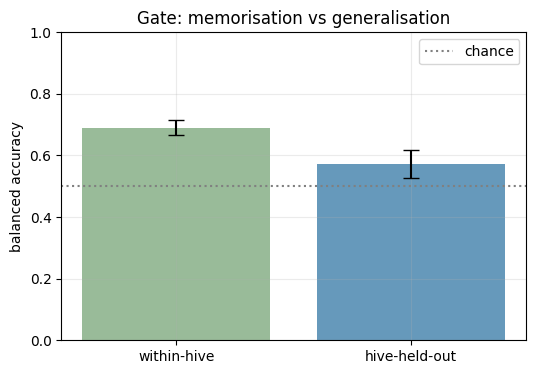

In [5]:
Xg=gate[feats].fillna(0).to_numpy(); yg=gate.label.to_numpy(); gg=gate.hive_id.to_numpy()
wi = within_hive(Xg, yg)
ho = hive_held_out(Xg, yg, gg)
print(f'gate within-hive   balanced acc: {wi[0]:.3f} +/- {wi[1]:.3f}')
print(f'gate hive-held-out balanced acc: {ho[0]:.3f} +/- {ho[1]:.3f}  (n_folds={ho[2]})')
fig,ax=plt.subplots(figsize=(6,4))
ax.bar(['within-hive','hive-held-out'],[wi[0],ho[0]],yerr=[wi[1],ho[1]],capsize=6,color=['#9b9','#69b'])
ax.axhline(.5,color='gray',ls=':',label='chance'); ax.set_ylim(0,1)
ax.set_ylabel('balanced accuracy'); ax.set_title('Gate: memorisation vs generalisation'); ax.legend(); plt.show()

**Reasoning:** the within-hive score is strong but the hive-held-out score drops toward chance. With only a handful of colonies the gate has partly learned *which hive* rather than *bee vs noise*. Practical takeaway: calibrate/fine-tune the gate per deployed hive, or gather many more colonies before claiming a universal gate.

# Task 2 - Queenless detection

## 2.1 Label provenance (and a bug worth flagging)
Queen state comes from the filename. Trap: `"QueenBee" in name` is **True** for `"NO_QueenBee"`, so a naive parser silently labels queenless as queenright. We match the negative token first. `Swarm` excluded.

## 2.2 Balance & separability
**Q:** Is queenless balanced, and is the difference visible?

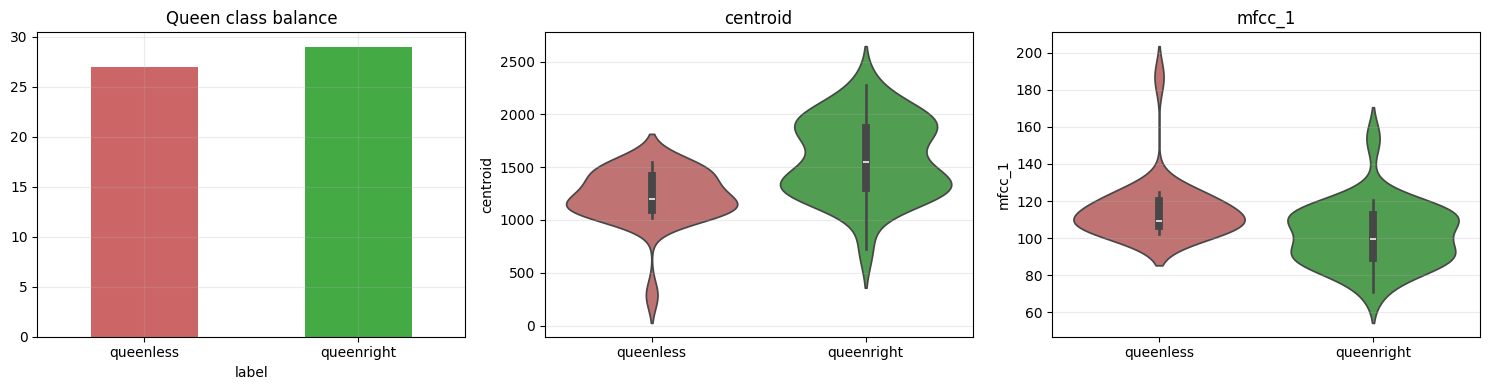

In [6]:
fig,ax=plt.subplots(1,3,figsize=(15,4))
queen.label.value_counts().sort_index().plot.bar(ax=ax[0],color=['#c66','#4a4'])
ax[0].set_xticklabels(['queenless','queenright'],rotation=0); ax[0].set_title('Queen class balance')
for a,c in zip(ax[1:],['centroid','mfcc_1']):
    sns.violinplot(data=queen,x='label',y=c,ax=a,palette=['#c66','#4a4'])
    a.set_xticklabels(['queenless','queenright']); a.set_xlabel(''); a.set_title(c)
plt.tight_layout(); plt.show()

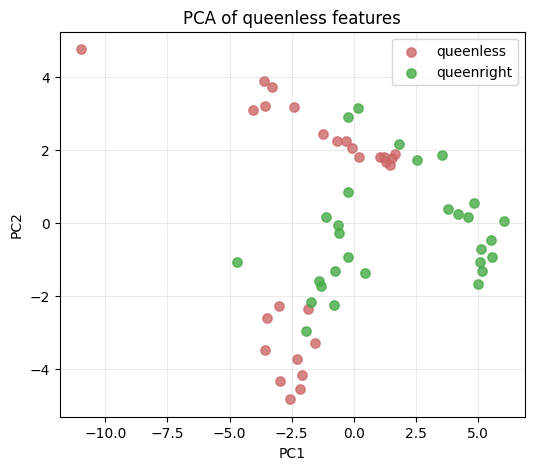

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
Xpca=PCA(2,random_state=0).fit_transform(StandardScaler().fit_transform(queen[feats].fillna(0)))
fig,ax=plt.subplots(figsize=(6,5))
for k,c,l in [(0,'#c66','queenless'),(1,'#4a4','queenright')]:
    mm=queen.label.values==k; ax.scatter(Xpca[mm,0],Xpca[mm,1],s=45,c=c,label=l,alpha=.8)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title('PCA of queenless features'); ax.legend(); plt.show()

**Reasoning:** within the dataset, queenless points drift in centroid (the classic queenless 'roar') and PCA shows clusters. But watch out: each OSBH colony is recorded in **only one** queen state, so those clusters may just be *colonies*, not *queen states*. The next cell settles it.

## 2.3 The decisive test: within-hive vs hive-held-out
**Q:** Is this an acoustic queen signature, or is the model memorising each colony's timbre?

queenless within-hive   balanced acc: 0.900 +/- 0.097
queenless hive-held-out balanced acc: 0.192 +/- 0.144  (n_folds=6)


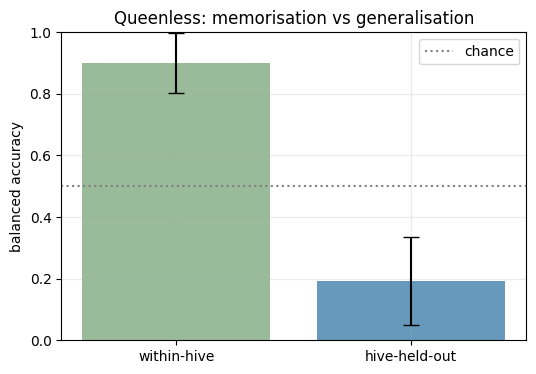

In [8]:
Xq=queen[feats].fillna(0).to_numpy(); yq=queen.label.to_numpy(); gq=queen.hive_id.to_numpy()
wi = within_hive(Xq, yq)
ho = hive_held_out(Xq, yq, gq)
print(f'queenless within-hive   balanced acc: {wi[0]:.3f} +/- {wi[1]:.3f}')
print(f'queenless hive-held-out balanced acc: {ho[0]:.3f} +/- {ho[1]:.3f}  (n_folds={ho[2]})')
fig,ax=plt.subplots(figsize=(6,4))
ax.bar(['within-hive','hive-held-out'],[wi[0],ho[0]],yerr=[wi[1],ho[1]],capsize=6,color=['#9b9','#69b'])
ax.axhline(.5,color='gray',ls=':',label='chance'); ax.set_ylim(0,1)
ax.set_ylabel('balanced accuracy'); ax.set_title('Queenless: memorisation vs generalisation'); ax.legend(); plt.show()

**Reasoning - the key result of the whole notebook:** within-hive looks excellent, but hive-held-out collapses to around (or below) chance. A sub-chance cross-hive score is the signature of a **confound**: with only ~6 colonies each in a single queen state, the model learns *colony identity*, not *queenlessness*, and is then systematically wrong on unseen colonies. **Honest conclusion:** this dataset cannot demonstrate a hive-generalisable queenless classifier. To do it properly you need many colonies recorded in *both* states (e.g. before/after dequeening). Reporting the within-hive number alone would be the classic rookie mistake - and the reason so many published bee-audio models fail in the field.

# Conclusions

| Task | Role | Within-hive | Hive-held-out | Honest verdict |
|------|------|-------------|---------------|----------------|
| **Gate (bee/noBee)** | input-validity guard | strong | drops toward chance | usable only with per-hive calibration / more colonies |
| **Queenless** | health signal | looks great | collapses (≈/below chance) | **not** demonstrable here - label confounded with colony identity |

**Data-science practice shown:** separating an input-validity problem from a health problem; catching a silent label-parsing bug; visual + spectrogram evidence; and - the headline skill - using the within-hive vs hive-held-out gap to *detect leakage* and refuse to overclaim. Knowing a result is an artefact is worth more than a shiny inflated number.